# Business Understanding

## Project Domain
Proyek ini berada di domain astrofisika, khususnya terkait pengelompokan atau klasifikasi bintang berdasarkan karakteristik fisiknya menggunakan teknik machine learning.

## Problem Statements
1. Data astronomi yang besar dan kompleks seringkali sulit dianalisis secara manual untuk mengklasifikasikan jenis-jenis bintang.

2. Dibutuhkan sistem otomatis yang mampu mengenali pola-pola dari atribut fisik bintang seperti suhu, luminositas, radius, dan warna.

3. Kesalahan klasifikasi atau pengelompokan bintang bisa berdampak pada pemahaman ilmiah yang keliru tentang evolusi dan struktur galaksi.

## Goals
1. Membangun model klasifikasi objek astronomi (galaksi, bintang, kuasar) berbasis Artificial Neural Network (ANN) menggunakan data fitur spektrum dan magnitudo dari dataset.

2. Mengoptimalkan arsitektur ANN untuk mencapai akurasi tinggi dalam membedakan objek langit berdasarkan pola non-linear antar fitur.

3. Melakukan evaluasi performa model ANN dibandingkan dengan baseline model konvensional (seperti Logistic Regression atau Decision Tree).

4. Memberikan alat bantu prediktif berbasis AI untuk mempercepat klasifikasi data observasi astronomi dalam studi lanjutan.

## Solution Statements
1. Melakukan pra-pemrosesan data untuk membersihkan dan menstandarkan atribut fisik bintang.

2. Menggunakan algoritma machine learning seperti ANN untuk mengklasifikasikan tipe bintang.

3. Mengevaluasi performa model menggunakan metrik seperti akurasi, confusion matrix, dan classification report untuk memastikan hasil yang valid dan dapat diandalkan.

# Data Understanding

## Import data dari kaggle

In [9]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mtyh05","key":"e9fa203f61eb2dd4aed418d8240f73c5"}'}

In [10]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [11]:
!kaggle datasets download -d datascientist97/astronomical-data

Dataset URL: https://www.kaggle.com/datasets/datascientist97/astronomical-data
License(s): other


In [12]:
!mkdir astronomical-data
!unzip astronomical-data.zip -d astronomical-data
!ls astronomical-data

mkdir: cannot create directory ‘astronomical-data’: File exists
Archive:  astronomical-data.zip
  inflating: astronomical-data/cleaned_star_data.csv  
cleaned_star_data.csv


## Import Library yang dibutuhkan

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

## Exploratory Data Analysis

In [14]:
df = pd.read_csv('astronomical-data/cleaned_star_data.csv')

In [15]:
df.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3042,0.0005,0.1542,16.6,0.0,Red,M
2,2600,0.0003,0.102,18.7,0.0,Red,M
3,2800,0.0002,,16.65,0.0,Red,M
4,1939,0.000138,0.103,20.06,0.0,Red,M


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         239 non-null    object 
 1   Luminosity(L/Lo)        239 non-null    object 
 2   Radius(R/Ro)            239 non-null    object 
 3   Absolute magnitude(Mv)  239 non-null    object 
 4   Star type               239 non-null    float64
 5   Star color              239 non-null    object 
 6   Spectral Class          239 non-null    object 
dtypes: float64(1), object(6)
memory usage: 13.3+ KB


In [17]:
numeric_cols = ['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [18]:
df = df.dropna()

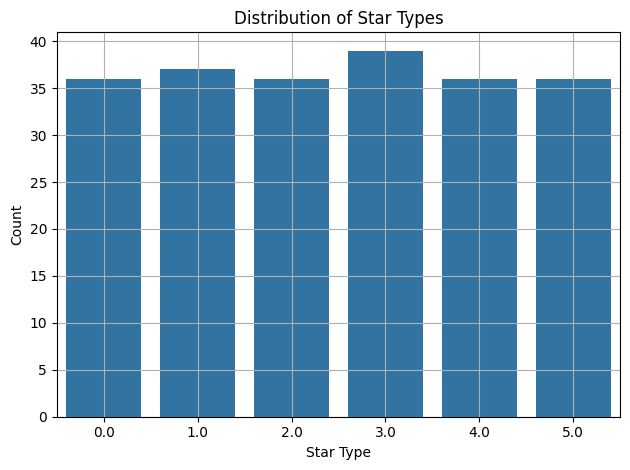

In [19]:
plt.figure()
sns.countplot(x='Star type', data=df)
plt.title('Distribution of Star Types')
plt.xlabel('Star Type')
plt.ylabel('Count')
plt.grid(True)
plt.tight_layout()
plt.show()

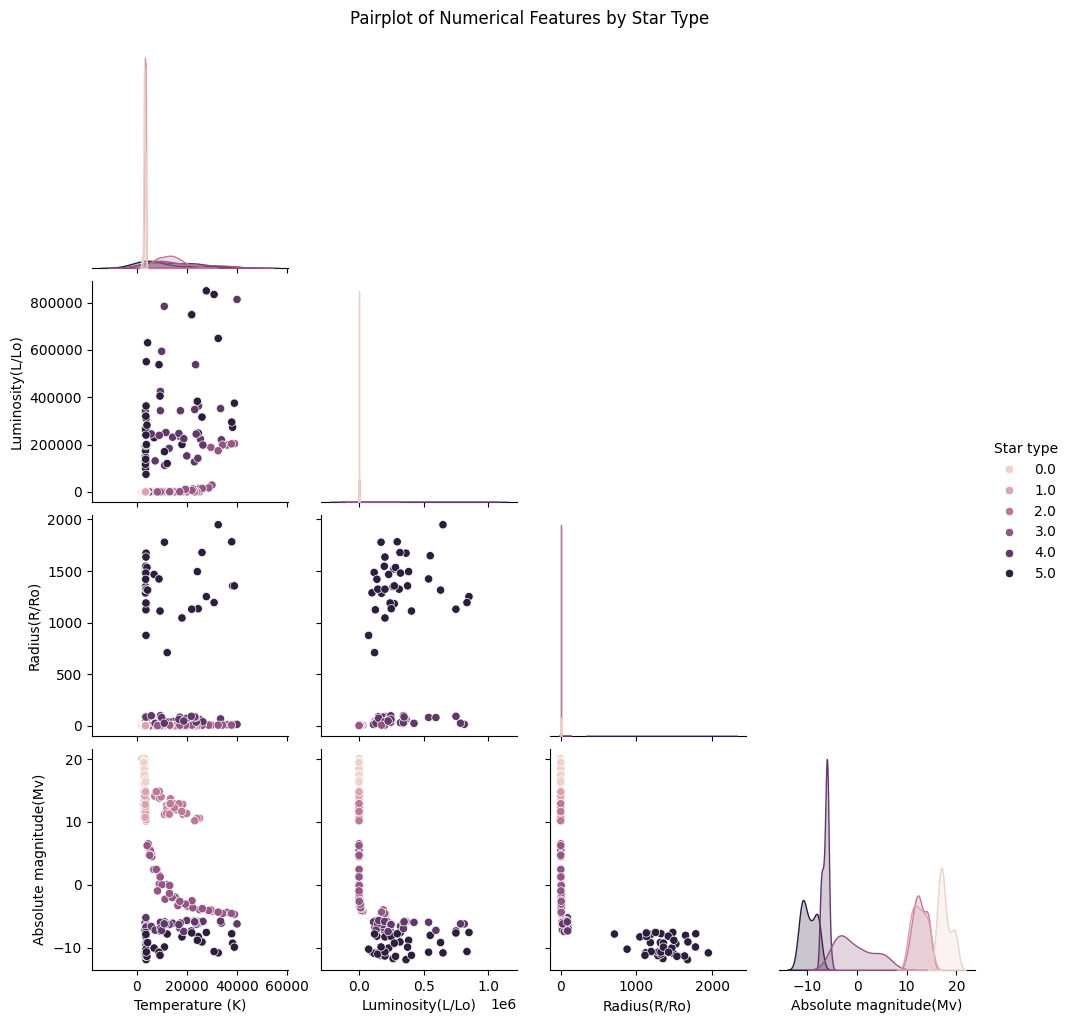

In [20]:
sns.pairplot(df, hue='Star type', vars=numeric_cols, corner=True)
plt.suptitle('Pairplot of Numerical Features by Star Type', y=1.02)
plt.show()

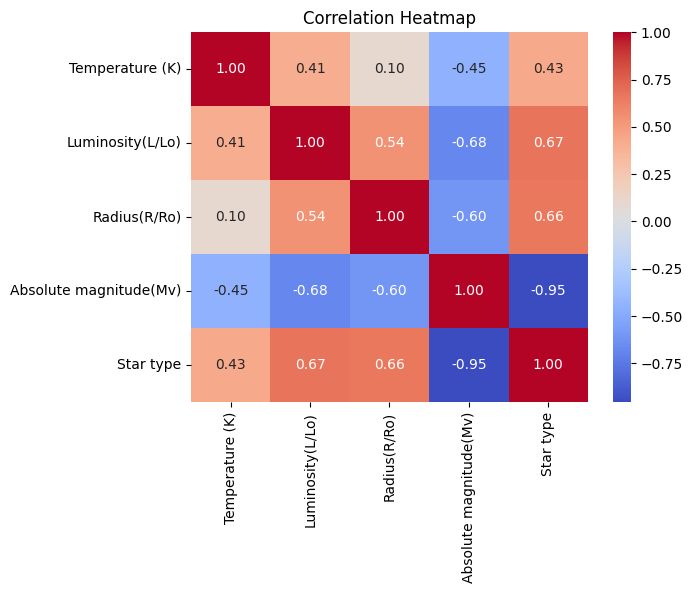

In [21]:
plt.figure()
corr = df[numeric_cols + ['Star type']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

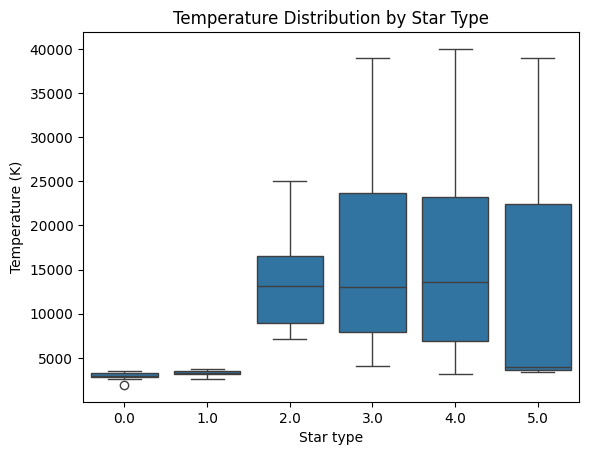

In [22]:
plt.figure()
sns.boxplot(x='Star type', y='Temperature (K)', data=df)
plt.title('Temperature Distribution by Star Type')
plt.show()

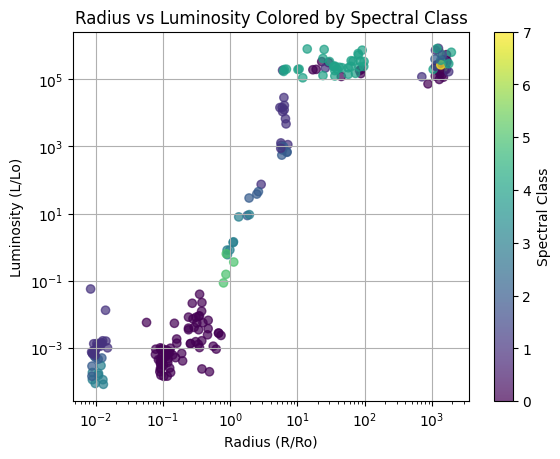

In [23]:
df['Spectral Class Encoded'] = pd.factorize(df['Spectral Class'])[0]
plt.figure()
scatter = plt.scatter(df['Radius(R/Ro)'], df['Luminosity(L/Lo)'],
                      c=df['Spectral Class Encoded'], cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Spectral Class')
plt.xlabel('Radius (R/Ro)')
plt.ylabel('Luminosity (L/Lo)')
plt.title('Radius vs Luminosity Colored by Spectral Class')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()

# Data Preparation

In [24]:
categorical_cols = ['Star color', 'Spectral Class']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [25]:
X = df.drop(columns=['Star type'])
y = df['Star type'].astype(int)

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [28]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (176, 7)
X_test shape: (44, 7)
y_train shape: (176,)
y_test shape: (44,)


# Modeling

In [29]:
num_classes = len(np.unique(y_train))

In [30]:
model = Sequential([
    Dense(64, input_shape=(X_train.shape[1],), activation='relu'),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')  # Softmax karena ini multiclass classification
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,790 (10.90 KB)

 Trainable params: 2,790 (10.90 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=50,
                    batch_size=16,
                    verbose=1)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.1723 - loss: 1.9082 - val_accuracy: 0.3333 - val_loss: 1.6429
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3265 - loss: 1.7215 - val_accuracy: 0.5556 - val_loss: 1.4554
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4562 - loss: 1.5708 - val_accuracy: 0.6944 - val_loss: 1.2949
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5602 - loss: 1.3797 - val_accuracy: 0.8056 - val_loss: 1.1463
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5628 - loss: 1.2984 - val_accuracy: 0.8056 - val_loss: 1.0232
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5909 - loss: 1.1864 - val_accuracy: 0.8056 - val_loss: 0.9117
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5615 - loss: 1.0725 - val_accuracy: 0.8333 - val_loss: 0.8109
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5900 - loss: 0.9740 - val_accuracy: 0.9444 - val_loss: 0.7235


# Evaluation

In [34]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0704
Akurasi Model: 1.0000
Loss Model: 0.0772


In [35]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.2%}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Accuracy: 100.00%


In [36]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

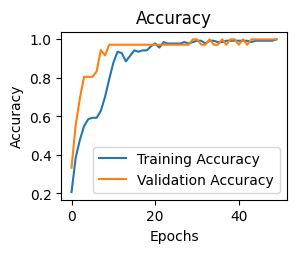

In [37]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

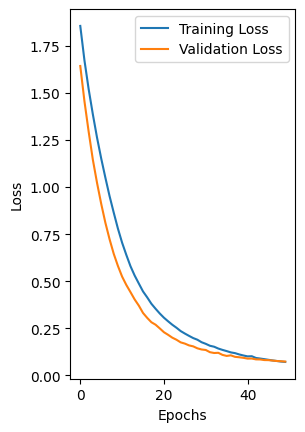

In [38]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


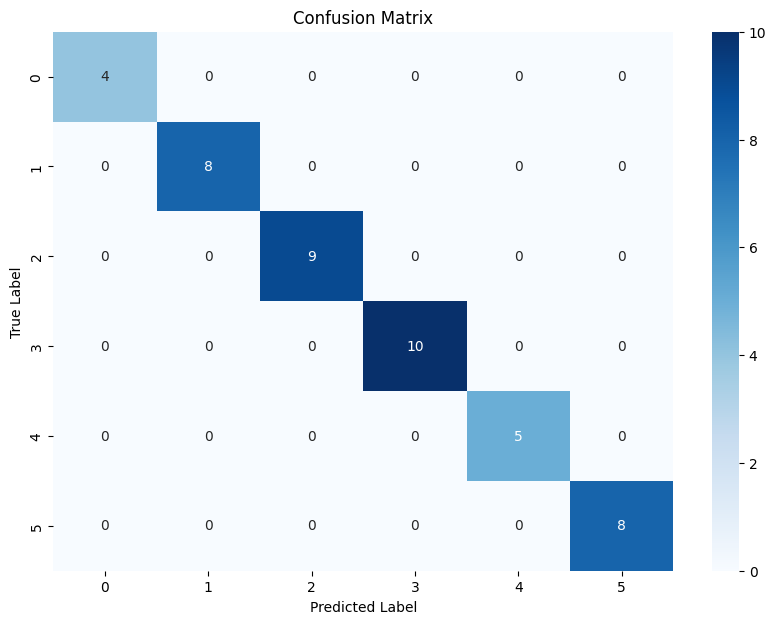

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         9
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         8

    accuracy                           1.00        44
   macro avg       1.00      1.00      1.00        44
weighted avg       1.00      1.00      1.00        44



In [39]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [40]:
sample_input = np.array([[78, 42 ,42, 20.13, 81.60,	7.62, 262.71]])
sample_input_df = pd.DataFrame(sample_input)

In [41]:
sample_input_scaled = scaler.transform(sample_input_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [42]:
predicted_class = np.argmax(model.predict(sample_input_scaled))
predicted_crop = le.inverse_transform([predicted_class])

print(f"Spectral Class: {predicted_crop[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Spectral Class: F


## Save Model

In [43]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('crop_recommendation.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpomv_mocn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  133870645400528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133870645401488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133870645402448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133870645403408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133870645399376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133870645403600: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [44]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']